# Model Comparison — All 4 Models

Compares `logistic_regression_baseline`, `logistic_regression`, `lightgbm`, `xgboost`.

All data is trimmed to the window starting at the **first trade of logistic_regression_baseline**
so all models are evaluated on the same time period.

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pyarrow.parquet as pq
from pathlib import Path

DATA = Path('../data/trades')
FEE = 0.02

MODELS = [
    ('logistic_regression_baseline', 'LR Baseline', 'steelblue'),
    ('logistic_regression',          'LR Full',     'darkorange'),
    ('lightgbm',                     'LightGBM',    'seagreen'),
    ('xgboost',                      'XGBoost',     'crimson'),
]

def load_model(model_id: str) -> pd.DataFrame:
    files = sorted(DATA.glob(f'{model_id}/trades_*.parquet'))
    if not files:
        return pd.DataFrame()
    df = pd.concat([pq.read_table(f).to_pandas() for f in files], ignore_index=True)
    df = df[df['pnl'].notna()].copy()
    df['opened_at'] = pd.to_datetime(df['opened_at'], utc=True)
    return df

raw = {mid: load_model(mid) for mid, _, _ in MODELS}

# Entry rules were updated at 2026-05-26 09:44:54 UTC.
# Use +5 min so only trades made under the new rules are included.
cutoff = pd.Timestamp('2026-05-26 09:49:54', tz='UTC')
print(f'Cutoff: {cutoff}')

dfs = {mid: raw[mid][raw[mid]['opened_at'] >= cutoff].copy() for mid, _, _ in MODELS}

for mid, label, _ in MODELS:
    d = dfs[mid]
    print(f'{label:25s}  {len(d):6,} trades  {d["market_id"].nunique():4} markets  '
          f'{d["opened_at"].min().strftime("%Y-%m-%d %H:%M")} → {d["opened_at"].max().strftime("%Y-%m-%d %H:%M")}')

Cutoff: 2026-05-26 09:49:54+00:00
LR Baseline                30,382 trades   227 markets  2026-05-26 10:20 → 2026-05-27 06:54
LR Full                    29,452 trades   223 markets  2026-05-26 10:21 → 2026-05-27 06:54
LightGBM                   28,707 trades   228 markets  2026-05-26 10:21 → 2026-05-27 06:52
XGBoost                    28,783 trades   227 markets  2026-05-26 10:21 → 2026-05-27 06:54


## 1. Top-level summary

In [31]:
rows = []
for mid, label, color in MODELS:
    d = dfs[mid]
    if len(d) == 0:
        continue
    wins = (d['pnl'] > 0).sum()
    total_pnl = d['pnl'].sum()
    roi = 100 * total_pnl / len(d)
    rows.append({
        'Model': label,
        'Trades': len(d),
        'Markets': d['market_id'].nunique(),
        'Win rate': f"{100*wins/len(d):.1f}%",
        'Total P&L': f"${total_pnl:+.2f}",
        'ROI/trade': f"{roi:+.3f}%",
        'Avg edge': f"{d['edge'].mean():.4f}",
        'Avg yes_px': f"{d['yes_price'].mean():.3f}",
        'Avg pred_prob': f"{d['predicted_prob'].mean():.3f}",
    })

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
summary_df = pd.DataFrame(rows).set_index('Model')
display(summary_df)

,Trades,Markets,Win rate,Total P&L,ROI/trade,Avg edge,Avg yes_px,Avg pred_prob
Model,,,,,,,,
LR Baseline,30382,227,48.5%,$-1579.25,-5.198%,0.0915,0.498,0.590
LR Full,29452,223,48.0%,$-1501.89,-5.099%,0.0958,0.498,0.594
LightGBM,28707,228,54.4%,$-1054.32,-3.673%,0.1786,0.553,0.732
XGBoost,28783,227,55.0%,$-1023.81,-3.557%,0.1766,0.558,0.735


## 2. Per-candle metrics

In [32]:
def per_candle(df):
    return df.groupby('market_id').agg(
        pnl=('pnl', 'sum'),
        trades=('pnl', 'count'),
        resolved_yes=('resolved_yes', 'first'),
        avg_edge=('edge', 'mean'),
        avg_yes=('yes_price', 'mean'),
        opened_at=('opened_at', 'min'),
    ).reset_index()

candles = {mid: per_candle(dfs[mid]) for mid, _, _ in MODELS if len(dfs[mid]) > 0}

rows = []
for mid, label, _ in MODELS:
    c = candles.get(mid)
    if c is None or len(c) == 0:
        continue
    wins = (c['pnl'] > 0).sum()
    rows.append({
        'Model': label,
        'Candles': len(c),
        'Candle win rate': f"{100*wins/len(c):.1f}%",
        'Total P&L': f"${c['pnl'].sum():+.2f}",
        'Mean P&L/candle': f"${c['pnl'].mean():+.2f}",
        'Median P&L/candle': f"${c['pnl'].median():+.2f}",
        'Worst candle': f"${c['pnl'].min():+.2f}",
        'Best candle': f"${c['pnl'].max():+.2f}",
        'Avg trades/candle': f"{c['trades'].mean():.1f}",
    })

display(pd.DataFrame(rows).set_index('Model'))

,Candles,Candle win rate,Total P&L,Mean P&L/candle,Median P&L/candle,Worst candle,Best candle,Avg trades/candle
Model,,,,,,,,
LR Baseline,227,50.2%,$-1579.25,$-6.96,$+1.94,$-261.00,$+984.61,133.8
LR Full,223,50.2%,$-1501.89,$-6.73,$+0.81,$-262.00,$+978.43,132.1
LightGBM,228,50.4%,$-1054.32,$-4.62,$+2.14,$-254.00,$+1006.21,125.9
XGBoost,227,50.7%,$-1023.81,$-4.51,$+2.21,$-262.00,$+1011.23,126.8


## 3. Cumulative P&L — all models on same chart

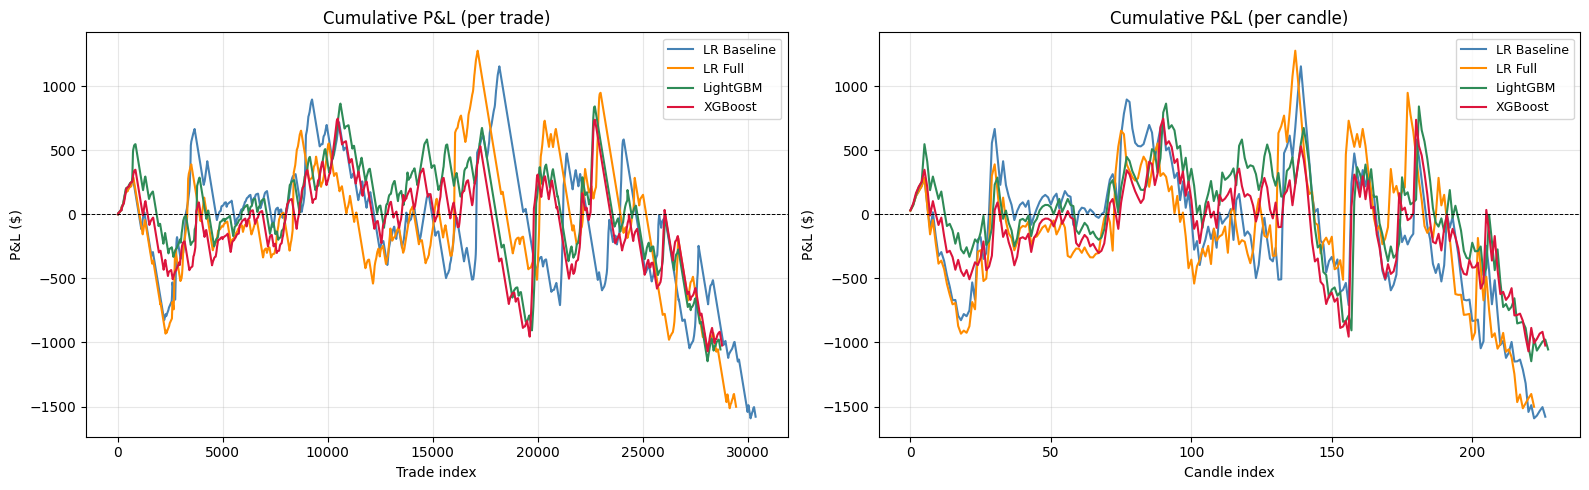

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: cumulative per-trade P&L
ax = axes[0]
for mid, label, color in MODELS:
    d = dfs[mid].sort_values('opened_at')
    if len(d) == 0:
        continue
    ax.plot(range(len(d)), d['pnl'].cumsum().values, label=label, color=color, linewidth=1.5)
ax.axhline(0, color='black', linewidth=0.7, linestyle='--')
ax.set_title('Cumulative P&L (per trade)')
ax.set_xlabel('Trade index')
ax.set_ylabel('P&L ($)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Right: cumulative per-candle P&L
ax = axes[1]
for mid, label, color in MODELS:
    c = candles.get(mid)
    if c is None or len(c) == 0:
        continue
    c_sorted = c.sort_values('opened_at')
    ax.plot(range(len(c_sorted)), c_sorted['pnl'].cumsum().values, label=label, color=color, linewidth=1.5)
ax.axhline(0, color='black', linewidth=0.7, linestyle='--')
ax.set_title('Cumulative P&L (per candle)')
ax.set_xlabel('Candle index')
ax.set_ylabel('P&L ($)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Per-candle P&L distribution

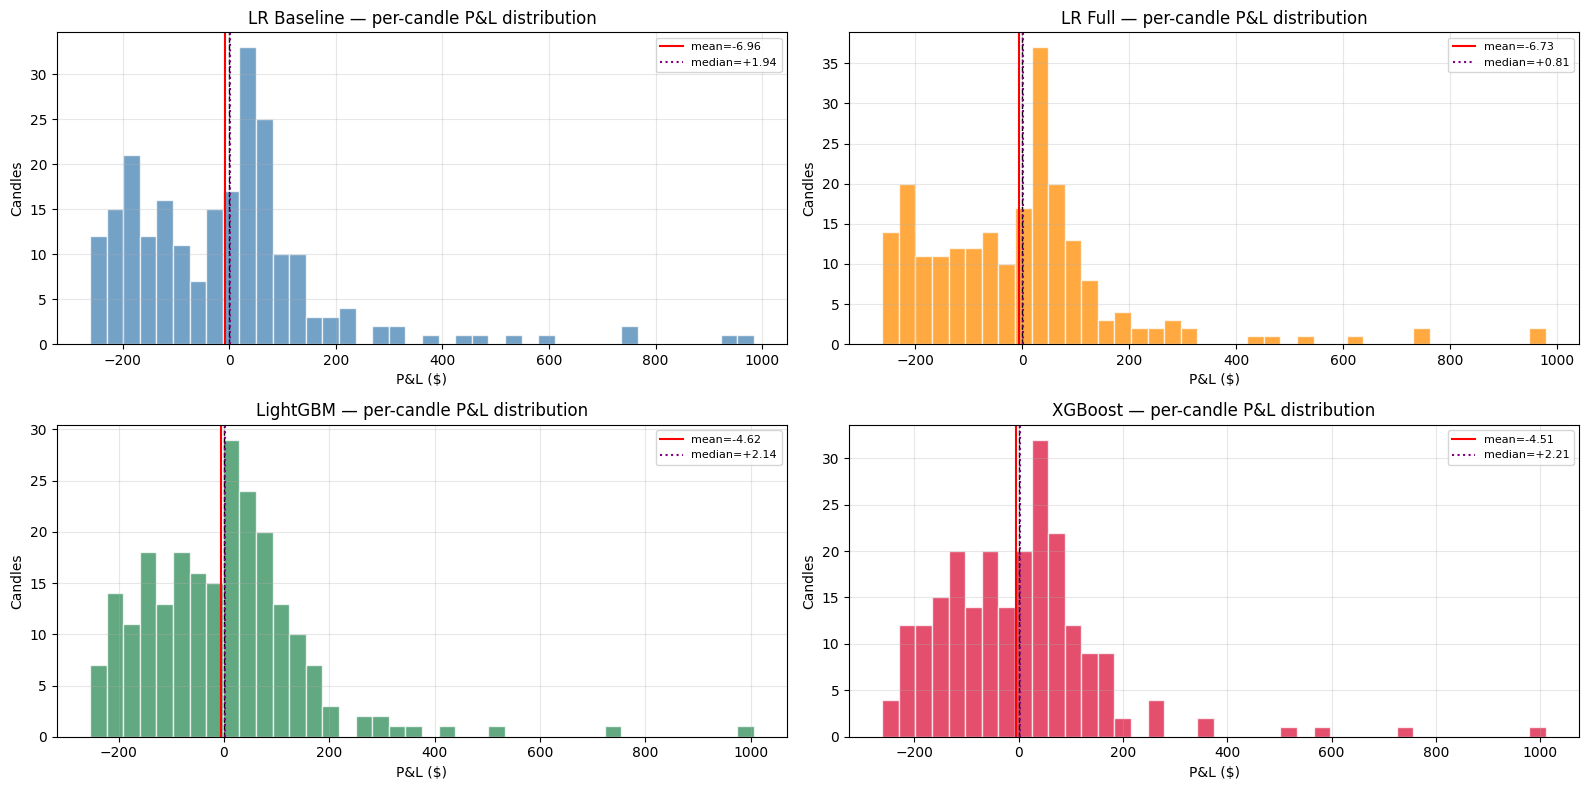

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
axes = axes.flatten()

for ax, (mid, label, color) in zip(axes, MODELS):
    c = candles.get(mid)
    if c is None or len(c) == 0:
        ax.set_visible(False)
        continue
    ax.hist(c['pnl'], bins=40, color=color, alpha=0.75, edgecolor='white')
    ax.axvline(0, color='black', linewidth=1, linestyle='--')
    ax.axvline(c['pnl'].mean(), color='red', linewidth=1.5, label=f'mean={c["pnl"].mean():+.2f}')
    ax.axvline(c['pnl'].median(), color='purple', linewidth=1.5, linestyle=':', label=f'median={c["pnl"].median():+.2f}')
    ax.set_title(f'{label} — per-candle P&L distribution')
    ax.set_xlabel('P&L ($)')
    ax.set_ylabel('Candles')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. P&L by edge bucket

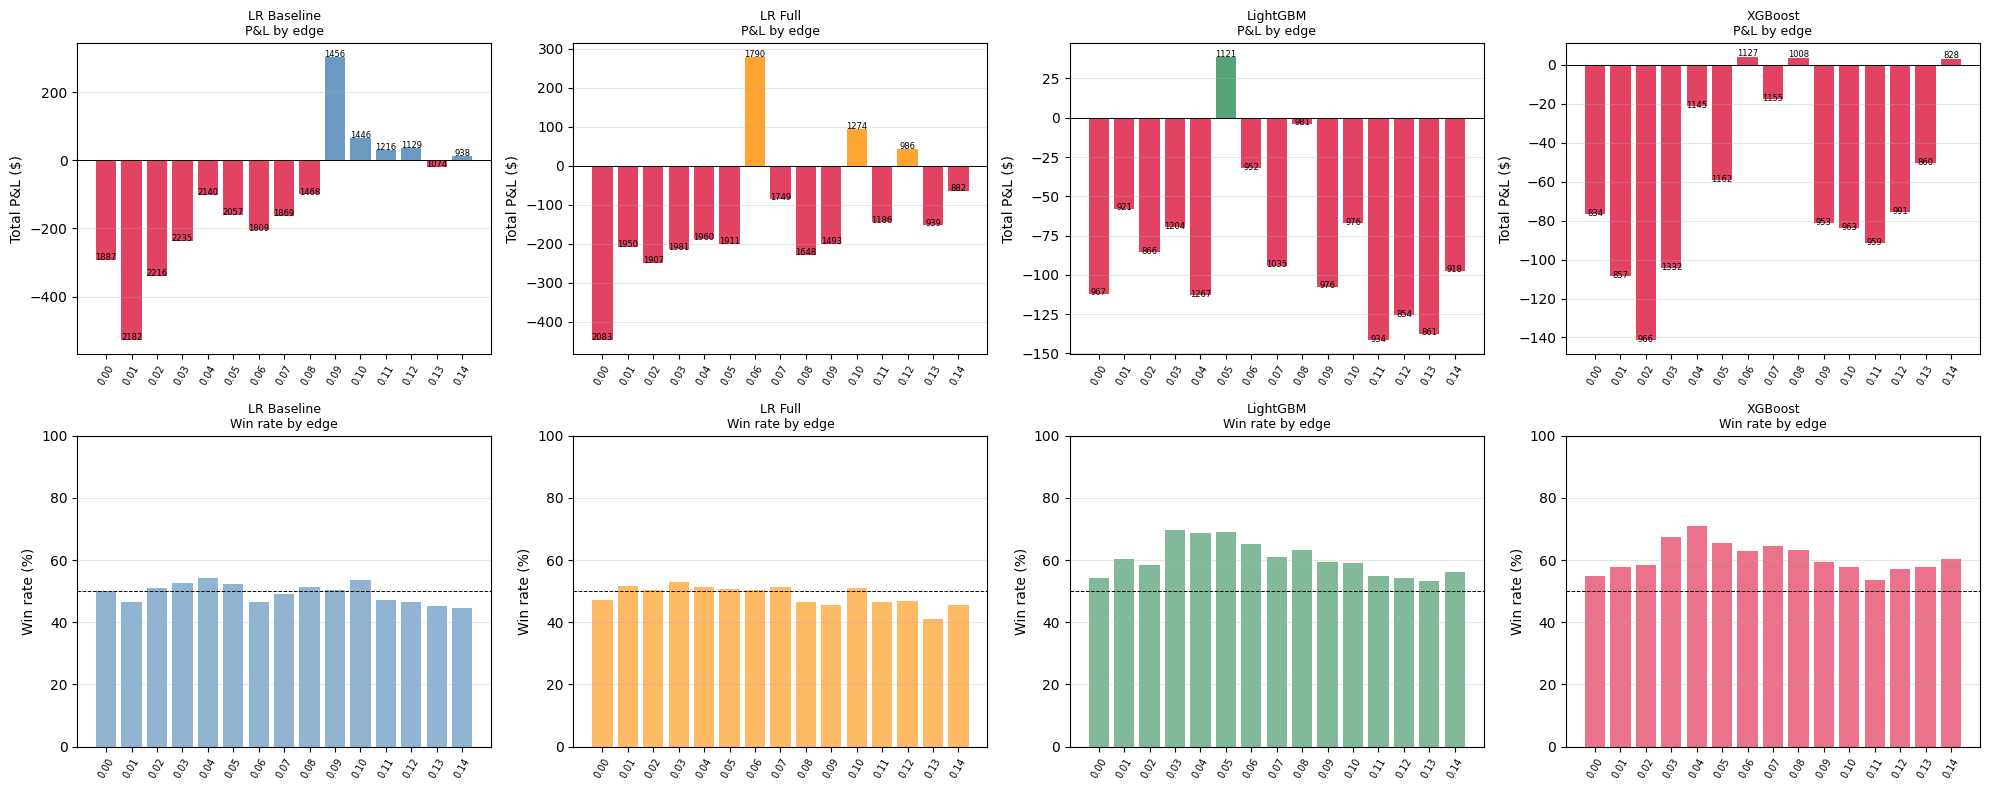

In [35]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))

bins = np.arange(0.00, 0.16, 0.01)

for col, (mid, label, color) in enumerate(MODELS):
    d = dfs[mid].copy()
    if len(d) == 0:
        continue
    d['eb'] = pd.cut(d['edge'], bins=bins)
    g = d.groupby('eb', observed=True).agg(
        total_pnl=('pnl', 'sum'),
        win_rate=('pnl', lambda x: 100 * (x > 0).mean()),
        n=('pnl', 'count'),
    )
    labels = [f'{b.left:.2f}' for b in g.index]
    x = range(len(g))

    ax_pnl = axes[0][col]
    ax_win = axes[1][col]

    ax_pnl.bar(x, g['total_pnl'], color=[color if v >= 0 else 'crimson' for v in g['total_pnl']], alpha=0.8)
    for i, (v, n) in enumerate(zip(g['total_pnl'], g['n'])):
        ax_pnl.text(i, v + (0.5 if v >= 0 else -1), f'{n}', ha='center', fontsize=6)
    ax_pnl.set_xticks(x)
    ax_pnl.set_xticklabels(labels, rotation=60, fontsize=7)
    ax_pnl.axhline(0, color='black', linewidth=0.7)
    ax_pnl.set_title(f'{label}\nP&L by edge', fontsize=9)
    ax_pnl.set_ylabel('Total P&L ($)')
    ax_pnl.grid(True, alpha=0.3, axis='y')

    ax_win.bar(x, g['win_rate'], color=color, alpha=0.6)
    ax_win.axhline(50, color='black', linewidth=0.7, linestyle='--')
    ax_win.set_xticks(x)
    ax_win.set_xticklabels(labels, rotation=60, fontsize=7)
    ax_win.set_title(f'{label}\nWin rate by edge', fontsize=9)
    ax_win.set_ylabel('Win rate (%)')
    ax_win.set_ylim(0, 100)
    ax_win.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 6. P&L by time remaining (15s bins)

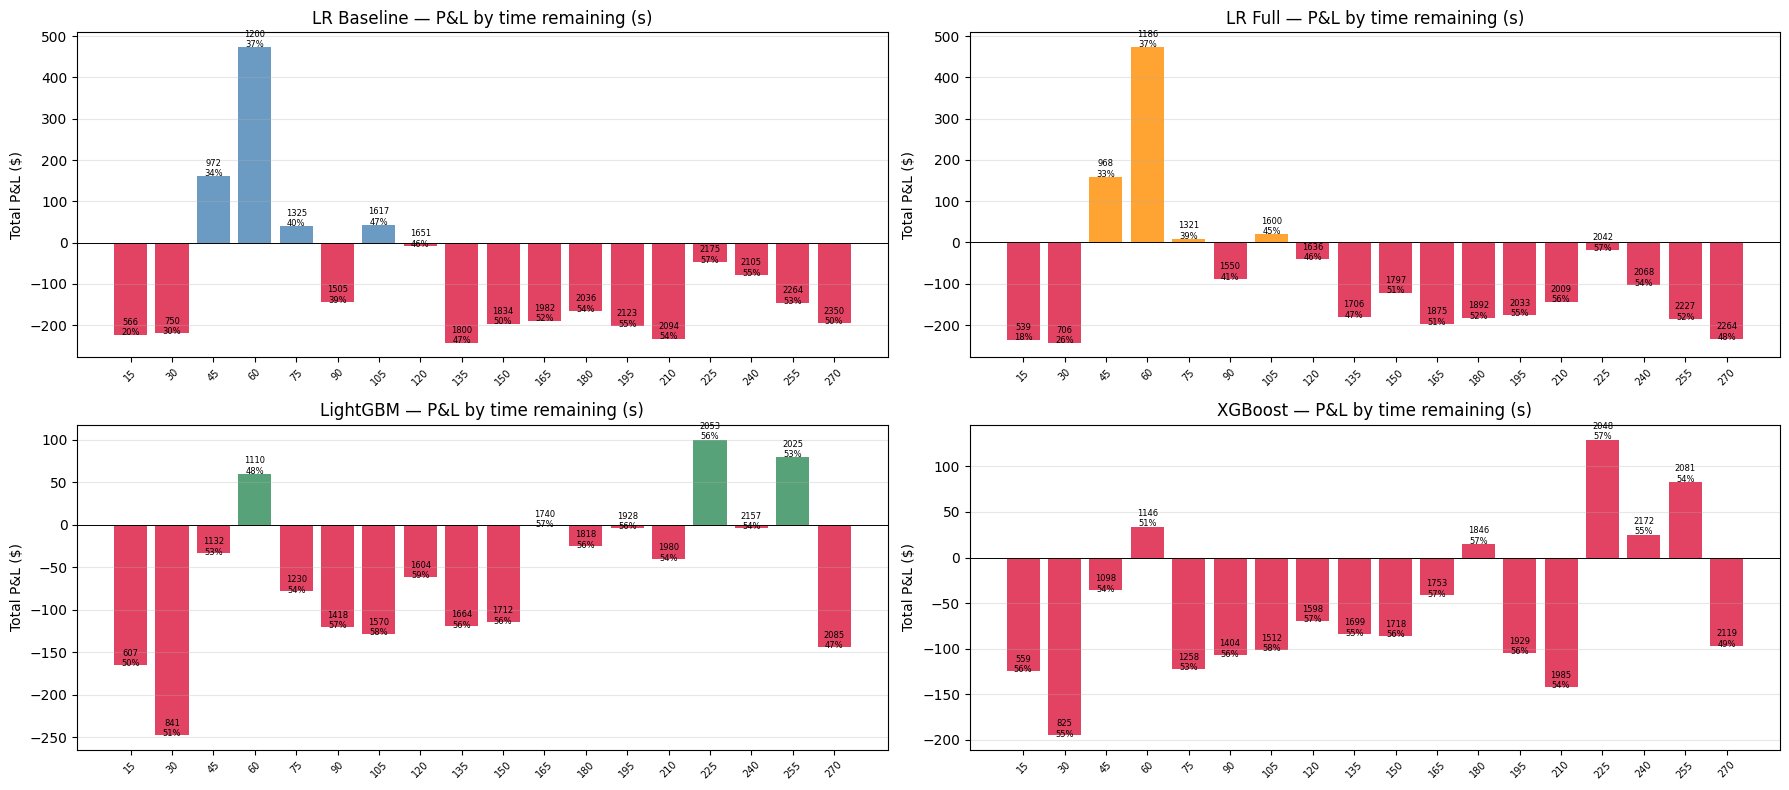

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(18, 8))
axes = axes.flatten()

time_bins = list(range(15, 300, 15))

for ax, (mid, label, color) in zip(axes, MODELS):
    d = dfs[mid].copy()
    if len(d) == 0:
        continue
    d['tb'] = pd.cut(d['time_remaining'], bins=time_bins)
    g = d.groupby('tb', observed=True).agg(
        total_pnl=('pnl', 'sum'),
        win_rate=('pnl', lambda x: 100 * (x > 0).mean()),
        n=('pnl', 'count'),
    )
    labels = [f'{int(b.left)}' for b in g.index]
    x = range(len(g))
    ax.bar(x, g['total_pnl'], color=[color if v >= 0 else 'crimson' for v in g['total_pnl']], alpha=0.8)
    for i, (v, n, wr) in enumerate(zip(g['total_pnl'], g['n'], g['win_rate'])):
        ax.text(i, v + (0.5 if v >= 0 else -1.5), f'{n}\n{wr:.0f}%', ha='center', fontsize=6)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, fontsize=7)
    ax.axhline(0, color='black', linewidth=0.7)
    ax.set_title(f'{label} — P&L by time remaining (s)')
    ax.set_ylabel('Total P&L ($)')
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 7. P&L by yes_price bucket (0.05 bins)

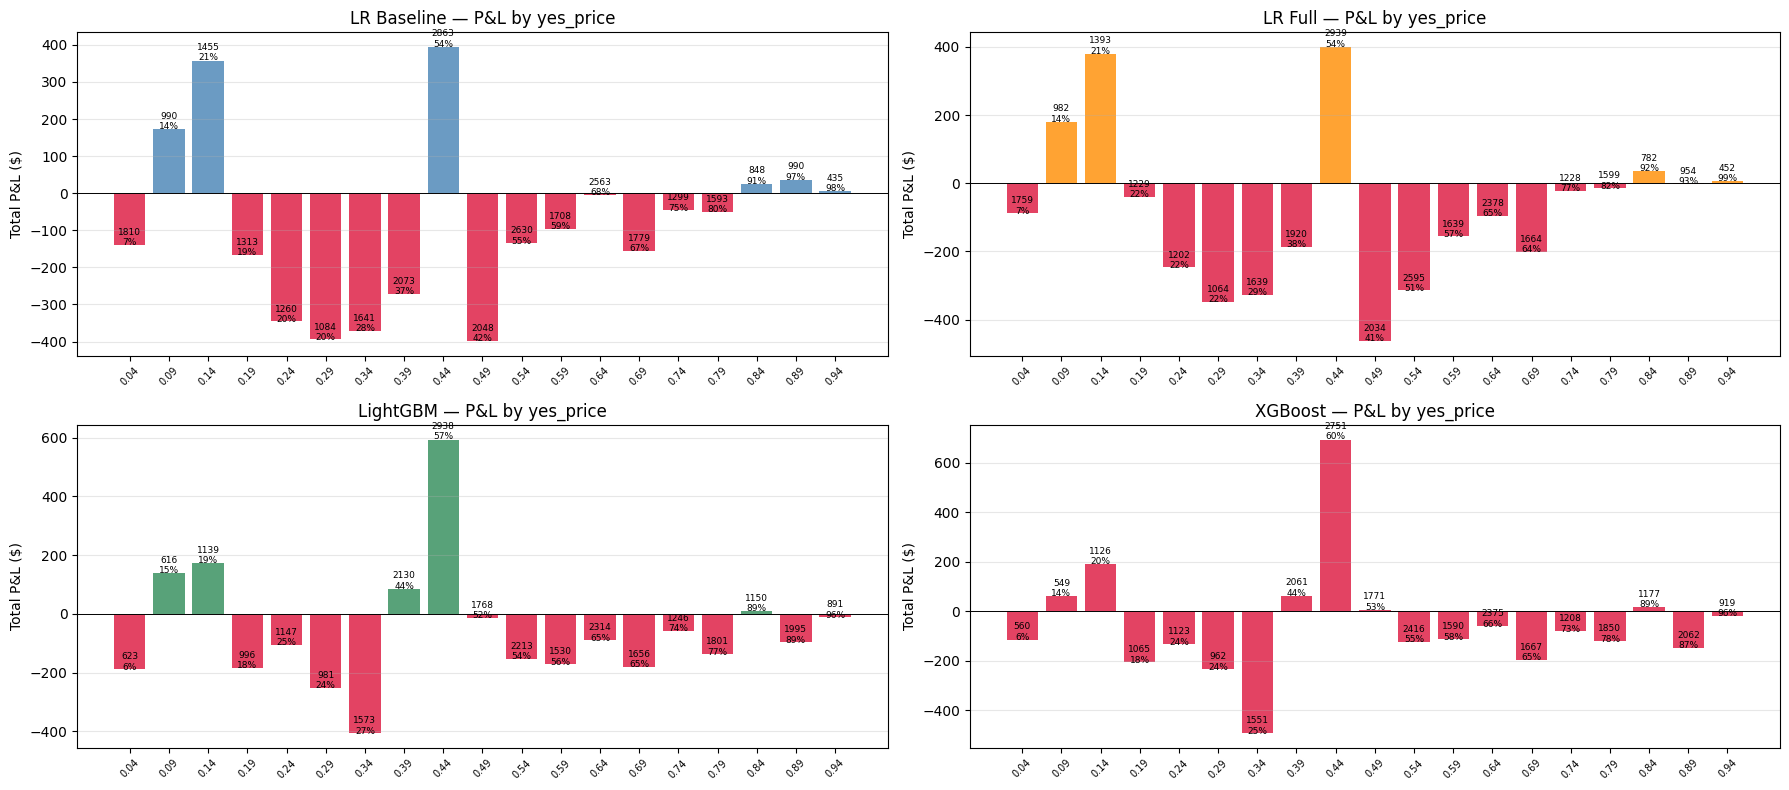

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(18, 8))
axes = axes.flatten()

price_bins = np.arange(0.04, 1.00, 0.05)

for ax, (mid, label, color) in zip(axes, MODELS):
    d = dfs[mid].copy()
    if len(d) == 0:
        continue
    d['pb'] = pd.cut(d['yes_price'], bins=price_bins)
    g = d.groupby('pb', observed=True).agg(
        total_pnl=('pnl', 'sum'),
        win_rate=('pnl', lambda x: 100 * (x > 0).mean()),
        n=('pnl', 'count'),
    )
    labels = [f'{b.left:.2f}' for b in g.index]
    x = range(len(g))
    ax.bar(x, g['total_pnl'], color=[color if v >= 0 else 'crimson' for v in g['total_pnl']], alpha=0.8)
    for i, (v, n, wr) in enumerate(zip(g['total_pnl'], g['n'], g['win_rate'])):
        ax.text(i, v + (0.5 if v >= 0 else -1.5), f'{n}\n{wr:.0f}%', ha='center', fontsize=6.5)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, fontsize=7)
    ax.axhline(0, color='black', linewidth=0.7)
    ax.set_title(f'{label} — P&L by yes_price')
    ax.set_ylabel('Total P&L ($)')
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 8. Calibration: predicted_prob vs actual win rate

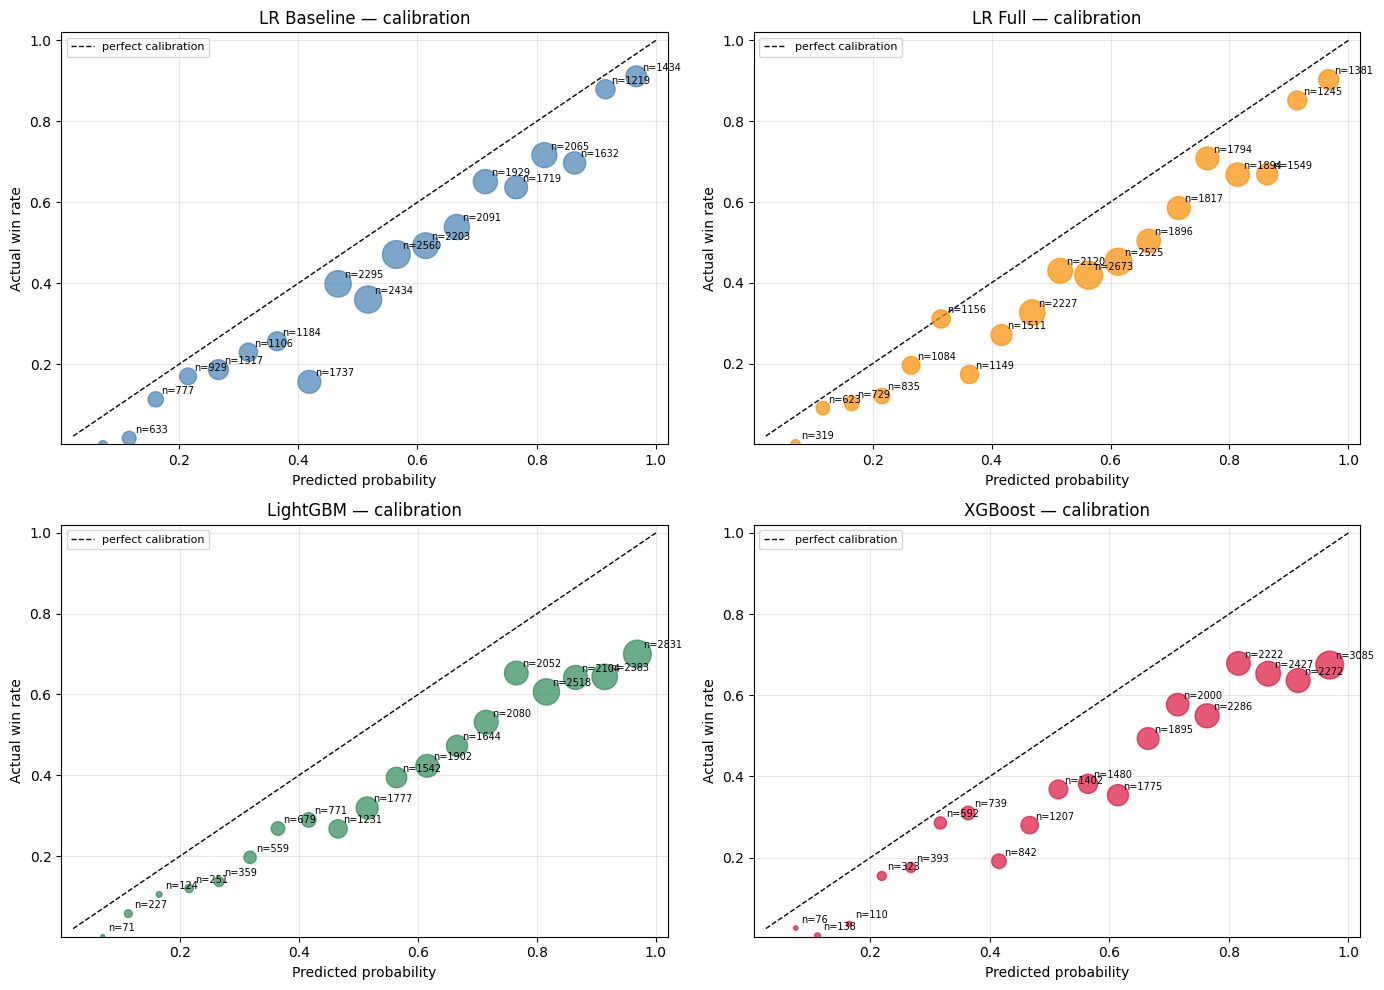

In [38]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (mid, label, color) in zip(axes, MODELS):
    d = dfs[mid].copy()
    if len(d) == 0:
        continue
    bins = np.arange(0.04, 1.00, 0.05)
    d['pred_bucket'] = pd.cut(d['predicted_prob'], bins=bins)
    g = d.groupby('pred_bucket', observed=True).agg(
        actual_win=('resolved_yes', lambda x: (x == True).mean()),
        n=('resolved_yes', 'count'),
        pred_mid=('predicted_prob', 'mean'),
    ).dropna()

    if len(g) == 0:
        continue

    ax.scatter(g['pred_mid'], g['actual_win'], s=g['n'] / g['n'].max() * 400,
               color=color, alpha=0.7, zorder=3)
    lo, hi = max(0, g['pred_mid'].min() - 0.05), min(1, g['pred_mid'].max() + 0.05)
    ax.plot([lo, hi], [lo, hi], 'k--', linewidth=1, label='perfect calibration')
    for _, row in g.iterrows():
        ax.annotate(f'n={int(row["n"])}', (row['pred_mid'], row['actual_win']),
                    textcoords='offset points', xytext=(4, 4), fontsize=7)
    ax.set_xlim(lo - 0.02, hi + 0.02)
    ax.set_ylim(lo - 0.02, hi + 0.02)
    ax.set_xlabel('Predicted probability')
    ax.set_ylabel('Actual win rate')
    ax.set_title(f'{label} — calibration')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. P&L on shared candles (same market_id appears in all models)

In [39]:
# Find markets covered by all 4 models
market_sets = [set(dfs[mid]['market_id'].unique()) for mid, _, _ in MODELS if len(dfs[mid]) > 0]
shared_markets = market_sets[0].intersection(*market_sets[1:])
print(f'Markets covered by all 4 models: {len(shared_markets)}')

candle_pnl = {}
for mid, label, _ in MODELS:
    d = dfs[mid][dfs[mid]['market_id'].isin(shared_markets)]
    candle_pnl[label] = d.groupby('market_id')['pnl'].sum()

shared_df = pd.DataFrame(candle_pnl)
shared_df = shared_df.dropna()

print(f'\nPer-candle P&L on shared markets:')
print(shared_df.describe().round(3))

print(f'\nCorrelation matrix:')
print(shared_df.corr().round(3))

Markets covered by all 4 models: 221

Per-candle P&L on shared markets:
       LR Baseline  LR Full  LightGBM   XGBoost
count      221.000  221.000   221.000   221.000
mean        -6.681   -6.628    -4.762    -4.626
std        191.686  191.055   156.608   156.962
min       -261.000 -262.000  -254.000  -262.000
25%       -146.000 -142.000  -114.000  -112.000
50%          2.381    2.381     2.143     2.207
75%         59.551   58.990    66.019    63.936
max        984.615  978.433  1006.214  1011.230

Correlation matrix:
             LR Baseline  LR Full  LightGBM  XGBoost
LR Baseline        1.000    0.991     0.883    0.895
LR Full            0.991    1.000     0.896    0.906
LightGBM           0.883    0.896     1.000    0.990
XGBoost            0.895    0.906     0.990    1.000


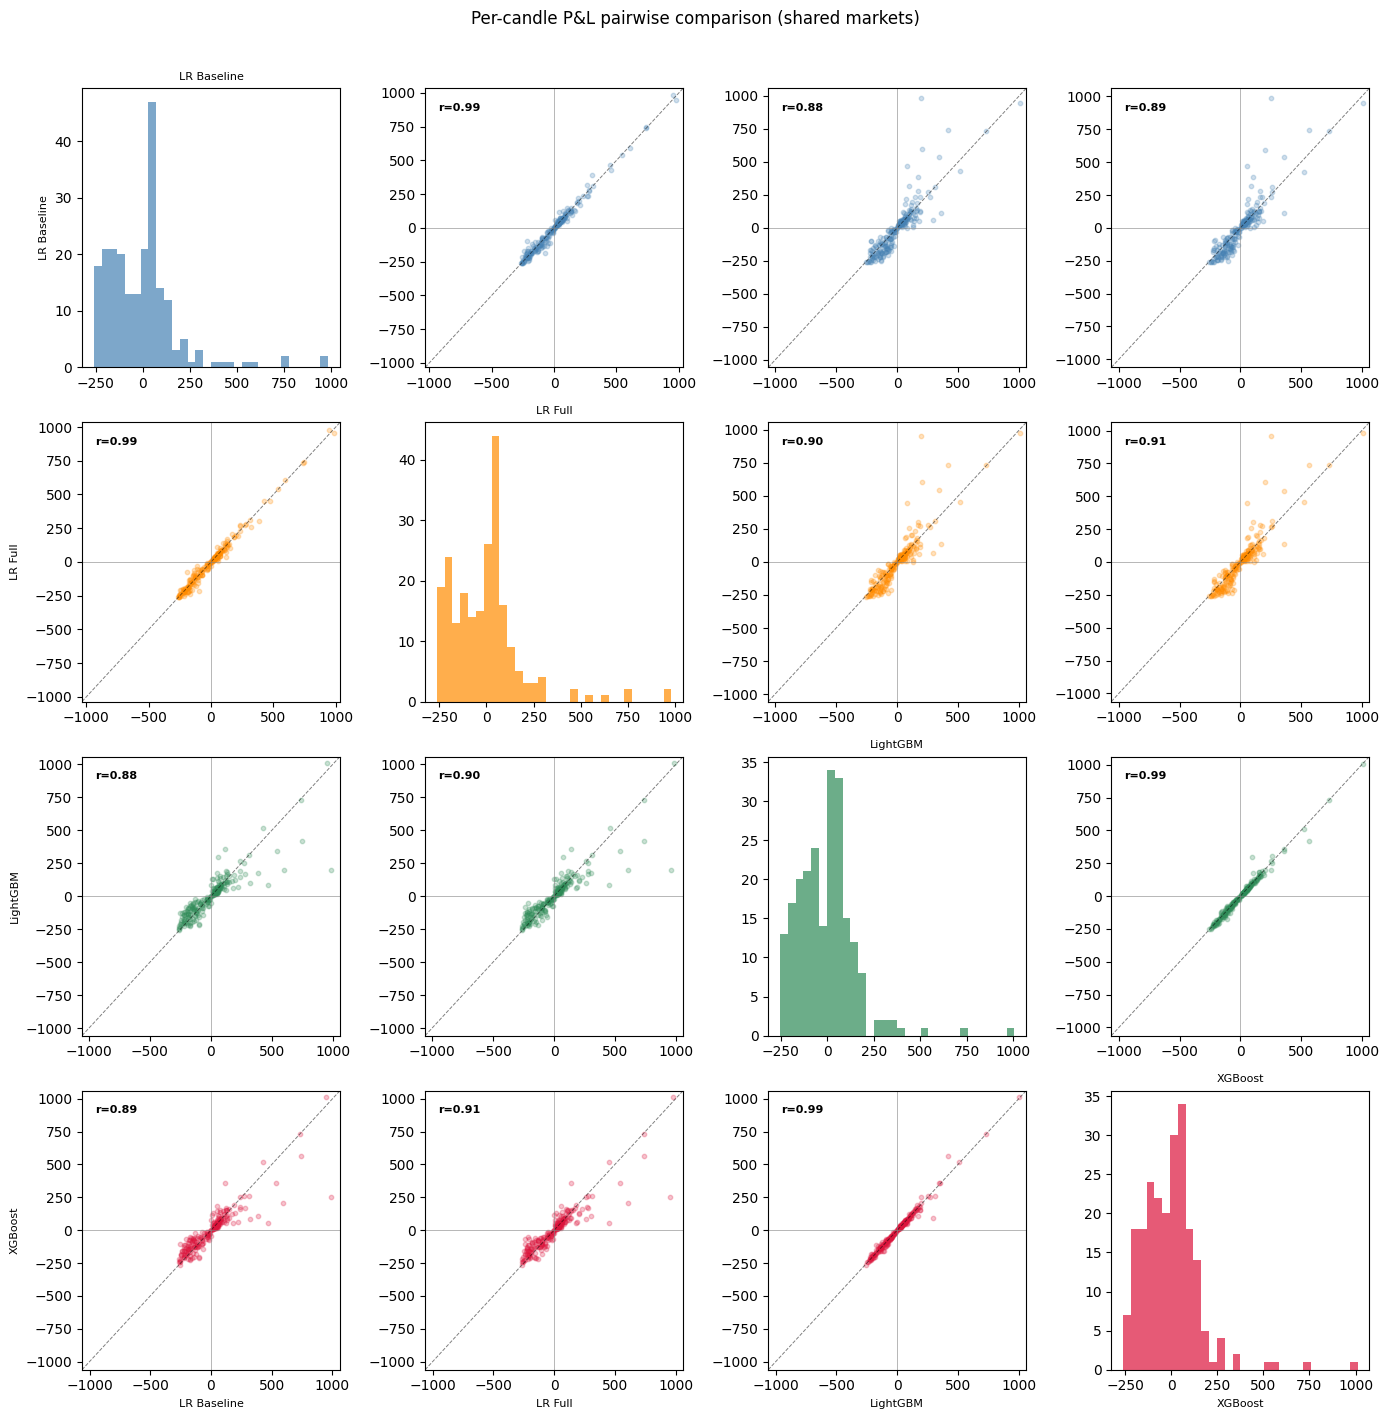

In [40]:
labels_list = [label for _, label, _ in MODELS]
n = len(labels_list)
fig, axes = plt.subplots(n, n, figsize=(14, 14))

for i, lx in enumerate(labels_list):
    for j, ly in enumerate(labels_list):
        ax = axes[i][j]
        if i == j:
            col = MODELS[i][2]
            ax.hist(shared_df[lx], bins=30, color=col, alpha=0.7)
            ax.set_title(lx, fontsize=8)
        else:
            corr = shared_df[lx].corr(shared_df[ly])
            ax.scatter(shared_df[ly], shared_df[lx], alpha=0.25, s=10,
                       color=MODELS[i][2])
            lim = max(abs(shared_df[lx]).max(), abs(shared_df[ly]).max()) * 1.05
            ax.set_xlim(-lim, lim)
            ax.set_ylim(-lim, lim)
            ax.plot([-lim, lim], [-lim, lim], 'k--', linewidth=0.7, alpha=0.5)
            ax.axhline(0, color='gray', linewidth=0.4)
            ax.axvline(0, color='gray', linewidth=0.4)
            ax.text(0.05, 0.92, f'r={corr:.2f}', transform=ax.transAxes, fontsize=8,
                    color='black', fontweight='bold')
        if j == 0:
            ax.set_ylabel(lx, fontsize=8)
        if i == n - 1:
            ax.set_xlabel(ly, fontsize=8)

plt.suptitle('Per-candle P&L pairwise comparison (shared markets)', y=1.01, fontsize=12)
plt.tight_layout()
plt.show()

## 10. Ensemble: combined signal from all 4 models on shared candles

In [41]:
shared_df['total'] = shared_df[labels_list].sum(axis=1)
shared_df['all_positive'] = (shared_df[labels_list] > 0).all(axis=1)
shared_df['all_negative'] = (shared_df[labels_list] < 0).all(axis=1)

print(f'Candles where ALL 4 models profit:   {shared_df["all_positive"].sum():4d}  '
      f'total P&L = ${shared_df.loc[shared_df["all_positive"], "total"].sum():+.2f}')
print(f'Candles where ALL 4 models lose:     {shared_df["all_negative"].sum():4d}  '
      f'total P&L = ${shared_df.loc[shared_df["all_negative"], "total"].sum():+.2f}')
print(f'Candles with mixed results:          {(~shared_df["all_positive"] & ~shared_df["all_negative"]).sum():4d}')
print()

# Agreement score: how many models agree on the direction
agreement = (shared_df[labels_list] > 0).sum(axis=1)
print('Majority vote breakdown (# models profitable on this candle):')
for k in range(5):
    mask = agreement == k
    n = mask.sum()
    pnl = shared_df.loc[mask, 'total'].sum()
    print(f'  {k}/4 profitable: {n:4d} candles  total P&L = ${pnl:+.2f}')

Candles where ALL 4 models profit:    112  total P&L = $+51797.96
Candles where ALL 4 models lose:      109  total P&L = $-56814.00
Candles with mixed results:             0

Majority vote breakdown (# models profitable on this candle):
  0/4 profitable:  109 candles  total P&L = $-56814.00
  1/4 profitable:    0 candles  total P&L = $+0.00
  2/4 profitable:    0 candles  total P&L = $+0.00
  3/4 profitable:    0 candles  total P&L = $+0.00
  4/4 profitable:  112 candles  total P&L = $+51797.96


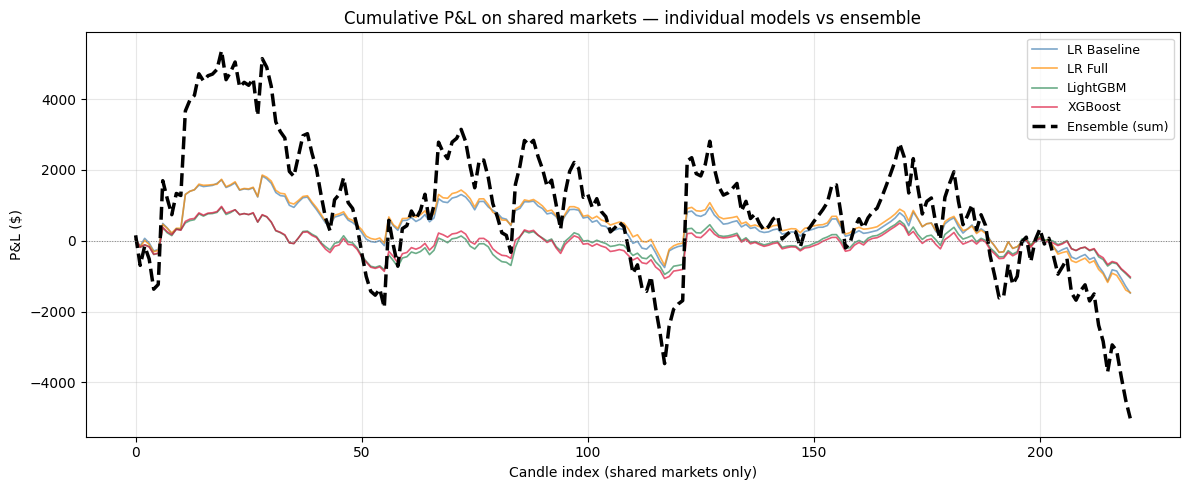

In [42]:
# Cumulative P&L on shared markets — naive equal-weight ensemble vs individual
fig, ax = plt.subplots(figsize=(12, 5))

for mid, label, color in MODELS:
    c = shared_df[[label]].sort_index()
    ax.plot(range(len(c)), c[label].cumsum().values, label=label, color=color, linewidth=1.2, alpha=0.7)

# Ensemble (sum of all 4)
c_sorted = shared_df.sort_index()
ax.plot(range(len(c_sorted)), c_sorted['total'].cumsum().values,
        label='Ensemble (sum)', color='black', linewidth=2.5, linestyle='--')

ax.axhline(0, color='gray', linewidth=0.7, linestyle=':')
ax.set_title('Cumulative P&L on shared markets — individual models vs ensemble')
ax.set_xlabel('Candle index (shared markets only)')
ax.set_ylabel('P&L ($)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Trades per candle — do high-volume candles hurt?

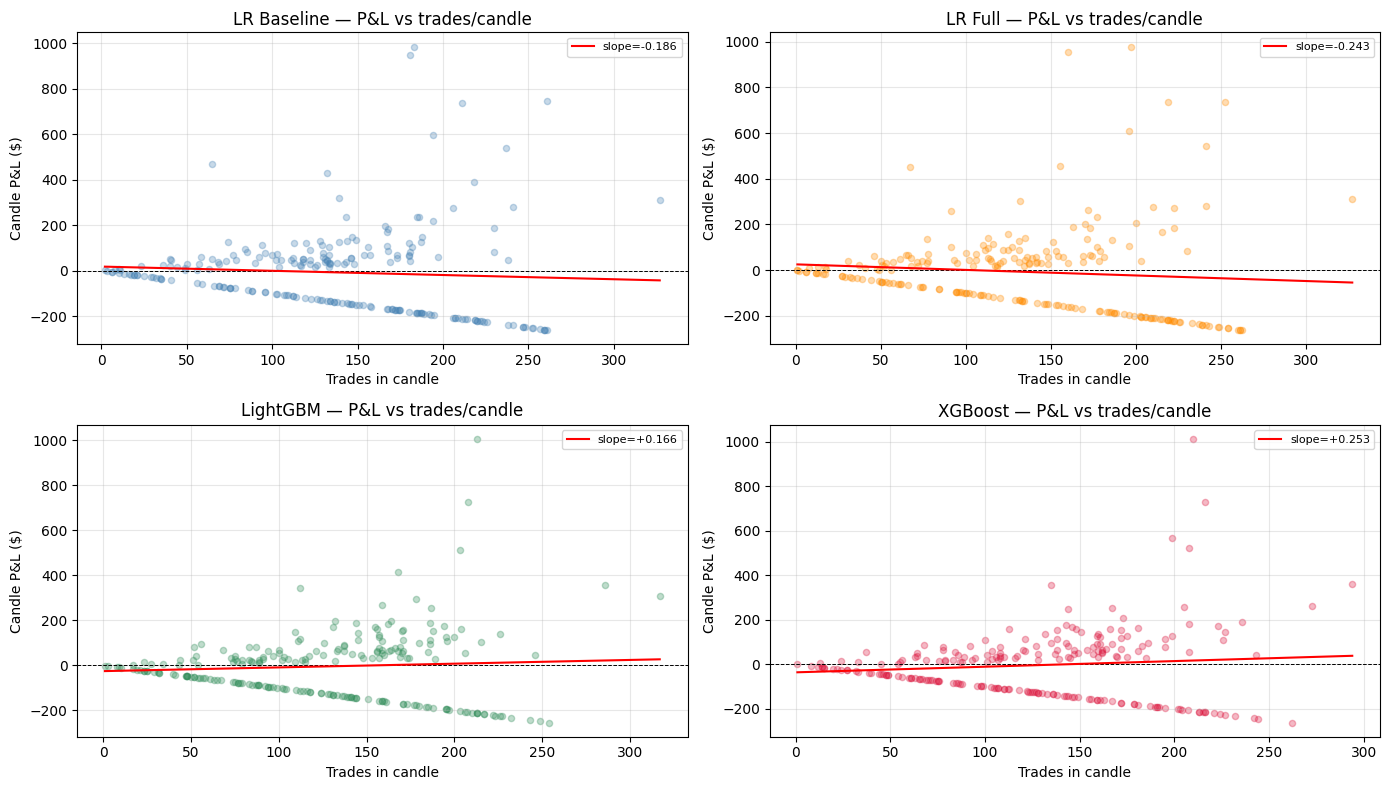

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, (mid, label, color) in zip(axes, MODELS):
    c = candles.get(mid)
    if c is None or len(c) == 0:
        continue
    ax.scatter(c['trades'], c['pnl'], alpha=0.3, s=20, color=color)
    ax.axhline(0, color='black', linewidth=0.7, linestyle='--')
    z = np.polyfit(c['trades'], c['pnl'], 1)
    p = np.poly1d(z)
    xs = np.linspace(c['trades'].min(), c['trades'].max(), 100)
    ax.plot(xs, p(xs), color='red', linewidth=1.5, label=f'slope={z[0]:+.3f}')
    ax.set_xlabel('Trades in candle')
    ax.set_ylabel('Candle P&L ($)')
    ax.set_title(f'{label} — P&L vs trades/candle')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 12. Interactive filter explorer

In [ ]:
import ipywidgets as widgets
from IPython.display import display

CUTOFF = pd.Timestamp('2026-05-26 09:49:54', tz='UTC')

model_labels = [label for _, label, _ in MODELS]
model_map    = {label: mid for mid, label, _ in MODELS}
color_map    = {label: color for _, label, color in MODELS}

# Compute pct_change_binance range across all models
all_pct = pd.concat([dfs[mid]['pct_change_binance'].dropna() for mid, _, _ in MODELS])
pct_lo  = float(np.floor(all_pct.quantile(0.01) * 1000) / 1000)
pct_hi  = float(np.ceil(all_pct.quantile(0.99) * 1000) / 1000)

model_w    = widgets.ToggleButtons(options=model_labels, description='Model:',
                                   style={'button_width': '100px'})
edge_min_w = widgets.FloatSlider(value=0.00, min=0.00, max=0.14, step=0.01,
                                  description='Edge min:', readout_format='.2f')
edge_max_w = widgets.FloatSlider(value=0.20, min=0.01, max=0.20, step=0.01,
                                  description='Edge max:', readout_format='.2f')
time_min_w = widgets.IntSlider(value=15,  min=15,  max=270, step=15, description='Time min:')
time_max_w = widgets.IntSlider(value=285, min=30,  max=285, step=15, description='Time max:')
price_min_w = widgets.FloatSlider(value=0.04, min=0.04, max=0.90, step=0.05,
                                   description='Price min:', readout_format='.2f')
price_max_w = widgets.FloatSlider(value=0.97, min=0.09, max=0.97, step=0.05,
                                   description='Price max:', readout_format='.2f')
pct_min_w  = widgets.FloatSlider(value=pct_lo, min=pct_lo, max=pct_hi, step=0.001,
                                  description='BTC% min:', readout_format='.3f')
pct_max_w  = widgets.FloatSlider(value=pct_hi, min=pct_lo, max=pct_hi, step=0.001,
                                  description='BTC% max:', readout_format='.3f')

out = widgets.Output()

def update(*_):
    mid   = model_map[model_w.value]
    color = color_map[model_w.value]
    df = dfs[mid][dfs[mid]['opened_at'] >= CUTOFF].copy()

    mask = (
        (df['edge']              >= edge_min_w.value)  & (df['edge']              <= edge_max_w.value)  &
        (df['time_remaining']    >= time_min_w.value)  & (df['time_remaining']    <= time_max_w.value)  &
        (df['yes_price']         >= price_min_w.value) & (df['yes_price']         <= price_max_w.value) &
        (df['pct_change_binance']>= pct_min_w.value)   & (df['pct_change_binance']<= pct_max_w.value)
    )
    filtered = df[mask].sort_values('opened_at')

    with out:
        out.clear_output(wait=True)
        if len(filtered) == 0:
            print('No trades match the current filters.')
            return

        wins      = (filtered['pnl'] > 0).sum()
        total_pnl = filtered['pnl'].sum()
        roi       = 100 * total_pnl / len(filtered)
        c         = per_candle(filtered)

        print(f'{model_w.value}  |  Trades: {len(filtered):,}  |  Candles: {len(c)}  |  '
              f'Win rate: {100*wins/len(filtered):.1f}%')
        print(f'Total P&L: ${total_pnl:+.2f}  |  ROI/trade: {roi:+.3f}%  |  '
              f'P&L/candle: ${c["pnl"].mean():+.2f}  |  Median P&L/candle: ${c["pnl"].median():+.2f}')

        fig, axes = plt.subplots(1, 3, figsize=(18, 4))

        # Cumulative P&L per candle
        c_sorted = c.sort_values('opened_at')
        axes[0].plot(c_sorted['pnl'].cumsum().values, color=color, linewidth=1.5)
        axes[0].axhline(0, color='black', linewidth=0.7, linestyle='--')
        axes[0].set_title('Cumulative P&L (per candle)')
        axes[0].set_xlabel('Candle index')
        axes[0].set_ylabel('P&L ($)')
        axes[0].grid(True, alpha=0.3)

        # P&L by edge bucket
        edge_bins = np.arange(edge_min_w.value, edge_max_w.value + 0.005, 0.01)
        if len(edge_bins) > 1:
            filtered['_eb'] = pd.cut(filtered['edge'], bins=edge_bins)
            g = filtered.groupby('_eb', observed=True)['pnl'].sum()
            axes[1].bar(range(len(g)), g.values,
                        color=[color if v >= 0 else 'crimson' for v in g.values], alpha=0.8)
            axes[1].set_xticks(range(len(g)))
            axes[1].set_xticklabels([f'{b.left:.2f}' for b in g.index], rotation=45, fontsize=8)
            axes[1].axhline(0, color='black', linewidth=0.7)
            axes[1].set_title('P&L by edge bucket')
            axes[1].grid(True, alpha=0.3, axis='y')

        # P&L by yes_price bucket
        price_bins = np.arange(price_min_w.value, price_max_w.value + 0.025, 0.05)
        if len(price_bins) > 1:
            filtered['_pb'] = pd.cut(filtered['yes_price'], bins=price_bins)
            g2 = filtered.groupby('_pb', observed=True)['pnl'].sum()
            axes[2].bar(range(len(g2)), g2.values,
                        color=[color if v >= 0 else 'crimson' for v in g2.values], alpha=0.8)
            axes[2].set_xticks(range(len(g2)))
            axes[2].set_xticklabels([f'{b.left:.2f}' for b in g2.index], rotation=45, fontsize=8)
            axes[2].axhline(0, color='black', linewidth=0.7)
            axes[2].set_title('P&L by yes_price bucket')
            axes[2].grid(True, alpha=0.3, axis='y')

        plt.tight_layout()
        plt.show()

for w in [model_w, edge_min_w, edge_max_w, time_min_w, time_max_w,
          price_min_w, price_max_w, pct_min_w, pct_max_w]:
    w.observe(update, names='value')

display(widgets.VBox([
    model_w,
    widgets.HBox([edge_min_w,  edge_max_w]),
    widgets.HBox([time_min_w,  time_max_w]),
    widgets.HBox([price_min_w, price_max_w]),
    widgets.HBox([pct_min_w,   pct_max_w]),
    out,
]))
update()